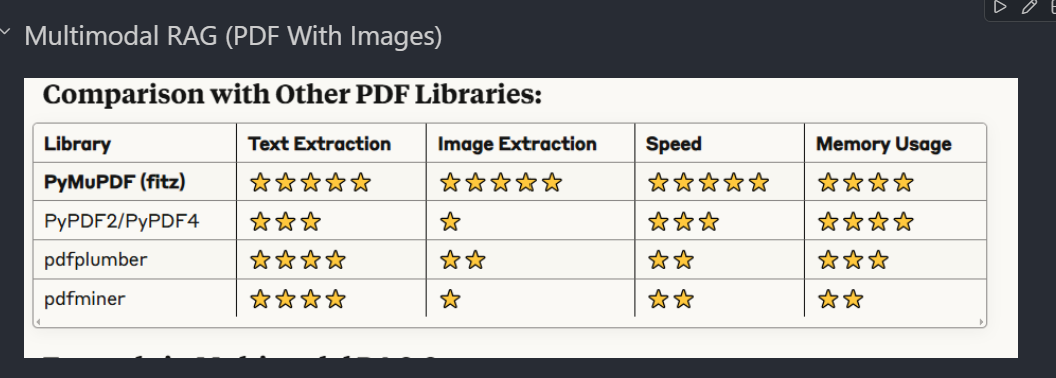

In [5]:
import fitz  # PyMuPDF
from langchain_core.documents import Document
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import numpy as np
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_classic.schema.messages import HumanMessage
from sklearn.metrics.pairwise import cosine_similarity
import os
import base64
import io
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

In [6]:
###Clip Model
import os
from dotenv import load_dotenv
load_dotenv()

## set up the environment
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

### initialize the Clip Model for unified embeddings
clip_model=CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor=CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()


c:\Users\Shradda\AppData\Local\Programs\Python\Python314\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Shradda\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 49939.66it/s]


CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, eleme

In [11]:
### Embedding functions
def embed_image(image_data):
    """Embed image using CLIP"""
    if isinstance(image_data, str):  # If path
        image = Image.open(image_data).convert("RGB")
    else:  # If PIL Image
        image = image_data

    inputs = clip_processor(images=image, return_tensors="pt")
    with torch.no_grad():
        out = clip_model.get_image_features(**inputs)
        features = _extract_tensor(out)
        # Normalize embeddings to unit vector
        features = features / features.norm(dim=-1, keepdim=True)
        return features.squeeze().cpu().numpy()
    
def _extract_tensor(output):
    """Return a tensor from a model output or pass-through if already a tensor."""
    if isinstance(output, torch.Tensor):
        return output
    # transformers base outputs often expose `pooler_output` or `last_hidden_state`
    if hasattr(output, 'pooler_output') and output.pooler_output is not None:
        return output.pooler_output
    if hasattr(output, 'last_hidden_state') and output.last_hidden_state is not None:
        # take CLS token / first token as pooled representation
        return output.last_hidden_state[:, 0]
    # fallback: try indexing like a tuple/list
    if isinstance(output, (tuple, list)) and len(output) > 0:
        candidate = output[0]
        if isinstance(candidate, torch.Tensor):
            return candidate
    raise ValueError('Unable to extract tensor from model output')

def embed_text(text):
    """Embed text using CLIP."""
    inputs = clip_processor(
        text=text, 
        return_tensors="pt", 
        padding=True,
        truncation=True,
        max_length=77  # CLIP's max token length
    )
    with torch.no_grad():
        out = clip_model.get_text_features(**inputs)
        features = _extract_tensor(out)
        # Normalize embeddings
        features = features / features.norm(dim=-1, keepdim=True)
        return features.squeeze().cpu().numpy()

In [12]:
## Process PDF
pdf_path="multimodal_sample.pdf"
doc=fitz.open(pdf_path)
# Storage for all documents and embeddings
all_docs = []
all_embeddings = []
image_data_store = {}  # Store actual image data for LLM

# Text splitter
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

In [13]:
doc

Document('multimodal_sample.pdf')

In [14]:
for i,page in enumerate(doc):
    ## process text
    text=page.get_text()
    if text.strip():
        ##create temporary document for splitting
        temp_doc = Document(page_content=text, metadata={"page": i, "type": "text"})
        text_chunks = splitter.split_documents([temp_doc])

        #Embed each chunk using CLIP
        for chunk in text_chunks:
            embedding = embed_text(chunk.page_content)
            all_embeddings.append(embedding)
            all_docs.append(chunk)



    ## process images
    ##Three Important Actions:

    ##Convert PDF image to PIL format
    ##Store as base64 for GPT-4V (which needs base64 images)
    ##Create CLIP embedding for retrieval

    for img_index, img in enumerate(page.get_images(full=True)):
        try:
            xref = img[0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image["image"]
            
            # Convert to PIL Image
            pil_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
            
            # Create unique identifier
            image_id = f"page_{i}_img_{img_index}"
            
            # Store image as base64 for later use with GPT-4V
            buffered = io.BytesIO()
            pil_image.save(buffered, format="PNG")
            img_base64 = base64.b64encode(buffered.getvalue()).decode()
            image_data_store[image_id] = img_base64
            
            # Embed image using CLIP
            embedding = embed_image(pil_image)
            all_embeddings.append(embedding)
            
            # Create document for image
            image_doc = Document(
                page_content=f"[Image: {image_id}]",
                metadata={"page": i, "type": "image", "image_id": image_id}
            )
            all_docs.append(image_doc)
            
        except Exception as e:
            print(f"Error processing image {img_index} on page {i}: {e}")
            continue

doc.close()


In [15]:
all_docs

[Document(metadata={'page': 0, 'type': 'text'}, page_content='Annual Revenue Overview\nThis document summarizes the revenue trends across Q1, Q2, and Q3. As illustrated in the chart\nbelow, revenue grew steadily with the highest growth recorded in Q3.\nQ1 showed a moderate increase in revenue as new product lines were introduced. Q2 outperformed\nQ1 due to marketing campaigns. Q3 had exponential growth due to global expansion.'),
 Document(metadata={'page': 0, 'type': 'image', 'image_id': 'page_0_img_0'}, page_content='[Image: page_0_img_0]')]

In [16]:
all_embeddings

[array([-2.67242640e-03,  1.28300143e-02, -5.18314019e-02,  4.14879508e-02,
        -2.33942028e-02, -7.55863870e-03, -3.67659144e-02,  1.19710609e-01,
         8.52081254e-02,  2.05426686e-03, -1.11534875e-02, -1.29592679e-02,
         5.25014587e-02, -3.65392724e-03,  4.76078689e-02,  1.58372782e-02,
         2.03388035e-02,  4.35362123e-02, -3.29168420e-03,  2.03181989e-02,
         1.88025588e-03, -4.23493832e-02,  5.44102304e-03,  3.70935947e-02,
        -1.65622998e-02,  6.48646709e-03, -4.78012338e-02,  8.67481343e-03,
         5.88859245e-02, -3.21394578e-02,  4.32439782e-02,  9.65301134e-03,
        -4.47921129e-03, -1.94858108e-02, -3.63502875e-02, -1.23471692e-02,
        -2.17929035e-02, -1.99016258e-02,  8.09620097e-02, -3.32986712e-02,
        -2.38901414e-02, -3.96139026e-02, -1.27279870e-02,  3.50380763e-02,
        -2.52217222e-02,  2.00031442e-03,  1.49660371e-02, -2.31976397e-02,
        -6.86791986e-02, -5.25789277e-04, -2.22545695e-02, -1.04103992e-02,
        -1.9

In [17]:
# Create unified FAISS vector store with CLIP embeddings
embeddings_array = np.array(all_embeddings)
embeddings_array

array([[-0.00267243,  0.01283001, -0.0518314 , ..., -0.00385087,
         0.0297772 , -0.00010684],
       [ 0.01732337, -0.0132769 , -0.02427029, ...,  0.0899405 ,
        -0.00272157,  0.03253039]], shape=(2, 512), dtype=float32)

In [18]:


# Create custom FAISS index since we have precomputed embeddings
vector_store = FAISS.from_embeddings(
    text_embeddings=[(doc.page_content, emb) for doc, emb in zip(all_docs, embeddings_array)],
    embedding=None,  # We're using precomputed embeddings
    metadatas=[doc.metadata for doc in all_docs]
)
vector_store

`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


In [19]:
# Initialize GPT-4 Vision model
llm = init_chat_model("openai:gpt-4.1")
llm

ChatOpenAI(output_version=None, profile={'name': 'GPT-4.1', 'release_date': '2025-04-14', 'last_updated': '2025-04-14', 'open_weights': False, 'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001C84DF7FB60>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001C84E3686E0>, root_client=<openai.OpenAI object at 0x000001C84DC0F0E0>, root_async_client=<openai.AsyncOpenAI object at 0x000001C84E368440>, model_name='gpt-4.1', model_kwargs={}, openai_

In [20]:
def retrieve_multimodal(query, k=5):
    """Unified retrieval using CLIP embeddings for both text and images."""
    # Embed query using CLIP
    query_embedding = embed_text(query)
    
    # Search in unified vector store
    results = vector_store.similarity_search_by_vector(
        embedding=query_embedding,
        k=k
    )
    
    return results

In [21]:
def create_multimodal_message(query, retrieved_docs):
    """Create a message with both text and images for GPT-4V."""
    content = []
    
    # Add the query
    content.append({
        "type": "text",
        "text": f"Question: {query}\n\nContext:\n"
    })
    
    # Separate text and image documents
    text_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "text"]
    image_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "image"]
    
    # Add text context
    if text_docs:
        text_context = "\n\n".join([
            f"[Page {doc.metadata['page']}]: {doc.page_content}"
            for doc in text_docs
        ])
        content.append({
            "type": "text",
            "text": f"Text excerpts:\n{text_context}\n"
        })
    
    # Add images
    for doc in image_docs:
        image_id = doc.metadata.get("image_id")
        if image_id and image_id in image_data_store:
            content.append({
                "type": "text",
                "text": f"\n[Image from page {doc.metadata['page']}]:\n"
            })
            content.append({
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{image_data_store[image_id]}"
                }
            })
    
    # Add instruction
    content.append({
        "type": "text",
        "text": "\n\nPlease answer the question based on the provided text and images."
    })
    
    return HumanMessage(content=content)

In [22]:
def multimodal_pdf_rag_pipeline(query):
    """Main pipeline for multimodal RAG."""
    # Retrieve relevant documents
    context_docs = retrieve_multimodal(query, k=5)
    
    # Create multimodal message
    message = create_multimodal_message(query, context_docs)
    
    # Get response from GPT-4V
    response = llm.invoke([message])
    
    # Print retrieved context info
    print(f"\nRetrieved {len(context_docs)} documents:")
    for doc in context_docs:
        doc_type = doc.metadata.get("type", "unknown")
        page = doc.metadata.get("page", "?")
        if doc_type == "text":
            preview = doc.page_content[:100] + "..." if len(doc.page_content) > 100 else doc.page_content
            print(f"  - Text from page {page}: {preview}")
        else:
            print(f"  - Image from page {page}")
    print("\n")
    
    return response.content

In [23]:
if __name__ == "__main__":
    # Example queries
    queries = [
        "What does the chart on page 1 show about revenue trends?",
        "Summarize the main findings from the document",
        "What visual elements are present in the document?"
    ]
    
    for query in queries:
        print(f"\nQuery: {query}")
        print("-" * 50)
        answer = multimodal_pdf_rag_pipeline(query)
        print(f"Answer: {answer}")
        print("=" * 70)


Query: What does the chart on page 1 show about revenue trends?
--------------------------------------------------

Retrieved 2 documents:
  - Text from page 0: Annual Revenue Overview
This document summarizes the revenue trends across Q1, Q2, and Q3. As illust...
  - Image from page 0


Answer: The chart on page 1 shows that revenue has increased steadily over the three quarters (Q1, Q2, and Q3). Each bar rises higher than the previous one:

- Q1 (blue bar) shows the lowest revenue, with a moderate increase.
- Q2 (green bar) shows higher revenue than Q1, reflecting improvements due to marketing efforts.
- Q3 (red bar) shows the highest revenue, indicating exponential growth, which the text attributes to global expansion.

Overall, the chart demonstrates a clear upward trend in revenue, with growth accelerating particularly in Q3.

Query: Summarize the main findings from the document
--------------------------------------------------

Retrieved 2 documents:
  - Text from page 0: Annua